In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class MoE(nn.Module):
    def __init__(self,in_dim=20,n_experts=4,expert_hidden=32,out_dim=5,k=2):
        super().__init__()
        self.k = k
        self.gate = nn.Linear(in_dim,n_experts)
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(in_dim,expert_hidden),nn.ReLU(),
                          nn.Linear(expert_hidden,out_dim))
            for _ in range(n_experts)
        ])
    def forward(self,x):
        scores = F.softmax(self.gate(x),dim=-1)
        topk_vals,topk_idx = scores.topk(self.k,dim=-1)
        topk_vals = topk_vals / topk_vals.sum(dim=-1,keepdim=True)
        out = torch.zeros(x.size(0),self.experts[0][-1].out_features,device=x.device)
        for i,expert in enumerate(self.experts):
            mask = (topk_idx == i).any(dim=-1)
            if mask.any():
                w = (topk_vals * (topk_idx == i)).sum(dim=-1)[mask].unsqueeze(-1)
                out[mask] += w * expert(x[mask])
        return out
model = MoE()
model.eval()
with torch.no_grad():
    out = model(torch.randn(8,20))
    print(out.shape)

torch.Size([8, 5])


torch.Size([8, 5])


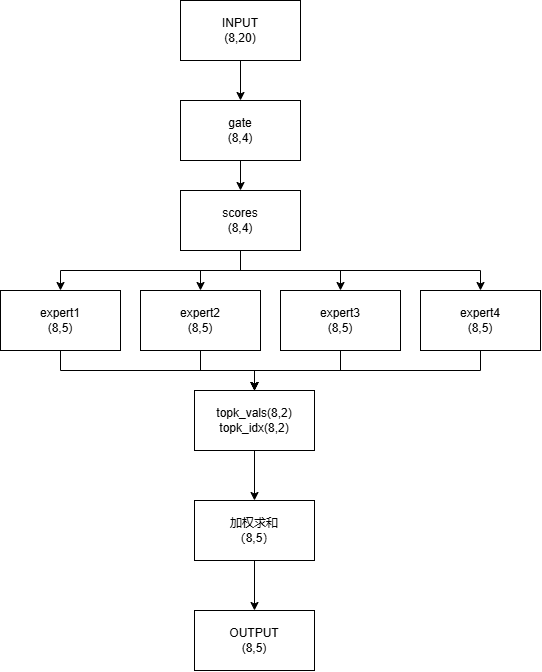

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class MoE(nn.Module):
    def __init__(self,in_dim=20,n_experts=4,expert_hidden=32,out_dim=5,k=2):
        super().__init__()
        self.k = k
        self.gate = nn.Linear(in_dim,n_experts)
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_dim,expert_hidden),nn.ReLU(),
                nn.Linear(expert_hidden,out_dim)
            )
            for _ in range(n_experts)
        ])
    def forward(self,x):
        scores = F.softmax(self.gate(x),dim=-1)
        topk_vals,topk_idx = scores.topk(self.k,dim=-1)
        topk_vals = topk_vals / topk_vals.sum(dim=-1,keepdim=True)
        out = torch.zeros(x.size(0),self.experts[0][-1].out_features,device=x.device)
        for i,expert in enumerate(self.experts):
            mask = (topk_idx == i).any(dim=-1)
            if mask.any():
                w = (topk_vals * (topk_idx == i)).sum(dim=-1)[mask].unsqueeze(-1)
                out[mask] += w * expert(x[mask])
        return out
model = MoE()
model.eval()
with torch.no_grad():
    out = model(torch.randn(8,20))
    print(out.shape)
from PIL import Image
import IPython.display as display
img = Image.open('MoE.png')
display.display(img)

tensor([[0.5059],
        [0.5059]])
tensor([[0.5118],
        [0.5110]])
torch.Size([2, 1, 32, 32])


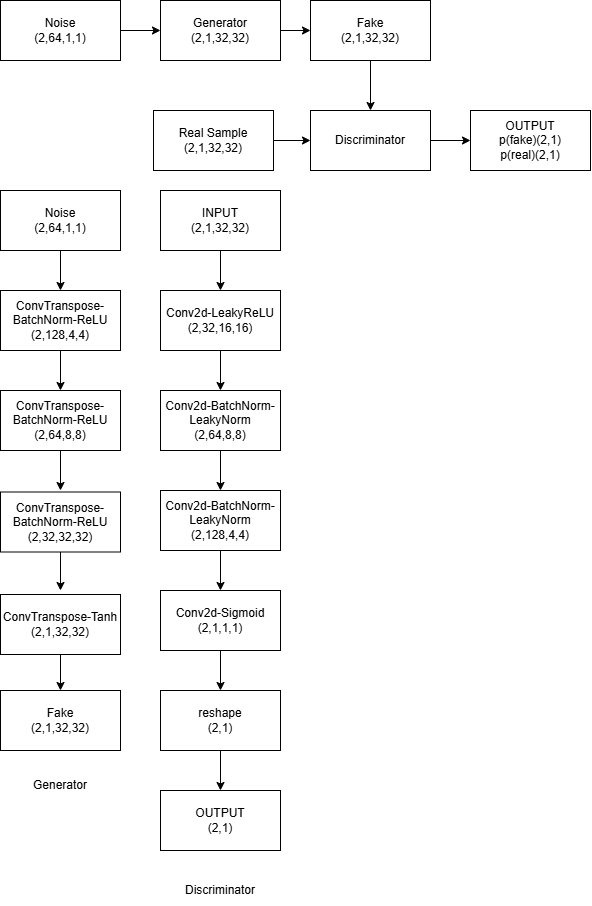

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class GAN(nn.Module):
    class Generator(nn.Module):
        def __init__(self,z=64,ch=32):
           super().__init__()
           self.net = nn.Sequential(
            nn.ConvTranspose2d(z,ch*4,4,2,0),nn.BatchNorm2d(ch*4),nn.ReLU(),
            nn.ConvTranspose2d(ch*4,ch*2,4,2,1),nn.BatchNorm2d(ch*2),nn.ReLU(),
            nn.ConvTranspose2d(ch*2,ch,4,2,1),nn.BatchNorm2d(ch),nn.ReLU(),
            nn.ConvTranspose2d(ch,1,4,2,1),nn.Tanh())
        def forward(self,z):
            return self.net(z.view(z.size(0),-1,1,1))
    class Discrimiator(nn.Module):
        def __init__(self,ch=32):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(1,ch,4,2,1),nn.LeakyReLU(0.2),
                nn.Conv2d(ch,ch*2,4,2,1),nn.BatchNorm2d(ch*2),nn.LeakyReLU(0.2),
                nn.Conv2d(ch*2,ch*4,4,2,1),nn.BatchNorm2d(ch*4),nn.LeakyReLU(),
                nn.Conv2d(ch*4,1,4,1,0),nn.Sigmoid(),
            )
        def forward(self,x):
            return self.net(x).view(x.size(0),1)
    def __init__(self):
        super().__init__()
        self.G = self.Generator()
        self.D = self.Discrimiator()
    def forward(self,z,real):
        fake = self.G(z)
        return self.D(fake),self.D(real),fake
model = GAN()
model.eval()
with torch.no_grad():
    out_fake,out_real,in_fake = model(torch.randn(2,64,1,1),torch.randn(2,1,32,32))
    print(out_fake)
    print(out_real)
    print(in_fake.shape)
from PIL import Image
import IPython.display as display
img = Image.open('GAN.png')
display.display(img)
    